In [1]:
!pip install -q -U datasets
!pip install -q grad-cam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 26.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 84.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 81.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requir

In [2]:
from datasets import load_dataset

data = load_dataset("mrJordi0/galaxy-zoo-dataset")
print(data)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/451M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/451M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/452M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/338M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/424M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/99808 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/24952 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/31191 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 99808
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 24952
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 31191
    })
})


In [3]:
print(data['train'].features)
print(data['train'][0])

{'image': Image(mode=None, decode=True), 'label': Value('int64')}
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=424x424 at 0x7958C245D610>, 'label': 0}


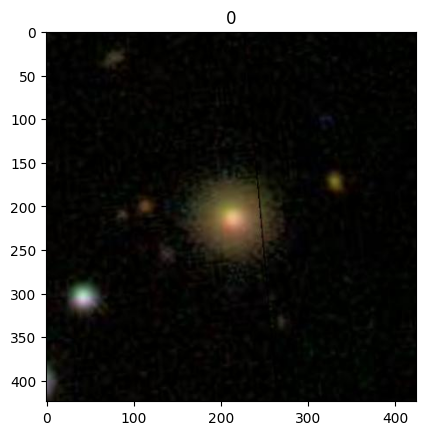

In [4]:
import matplotlib.pyplot as plt

sample = data['train'][0]
plt.imshow(sample['image'])
plt.title(sample['label'])
plt.show()

In [5]:
class_names = [
    'round elliptical',
    'in-between elliptical',
    'cigar-shaped elliptical',
    'edge-on spiral',
    'barred spiral',
    'unbarred spiral',
    'irregular',
    'merger'
]

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [7]:
class GalaxyDataset(Dataset):
    def __init__(self, hf_data, transform):
        self.hf_data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.hf_data)

    def __getitem__(self, idx):
        item = self.hf_data[idx]
        img = item['image'].convert('RGB')
        label = item['label']
        img = self.transform(img)
        return img, label

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(360),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [9]:
train_dataset = GalaxyDataset(data['train'], train_transform)
val_dataset = GalaxyDataset(data['validation'], val_transform)
test_dataset = GalaxyDataset(data['test'], val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [10]:
labels_list = data['train']['label']

counts = {}
for label in labels_list:
    if label in counts:
        counts[label] += 1
    else:
        counts[label] = 1

print(counts)

{0: 21683, 2: 4766, 7: 1361, 1: 25111, 4: 13029, 5: 19653, 3: 10436, 6: 3769}


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

total_samples = len(labels_list)
num_classes = 8

class_weights = []
for i in range(num_classes):
    weight = total_samples / (num_classes * counts[i])
    class_weights.append(weight)

print(class_weights)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

[0.5753816353825577, 0.4968340567878619, 2.6177087704574067, 1.1954771943273286, 0.9575562207383529, 0.6348140233043301, 3.310161846643672, 9.166789125642909]


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 8)
model = model.to(device)

cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


In [13]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=22)

# **training loop**

In [14]:
from tqdm import tqdm

num_epochs = 22
best_acc = 0

train_loss_history = []
train_acc_history = []
val_acc_history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"epoch {epoch+1}")
    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item())

    scheduler.step()
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f"epoch {epoch+1}, loss {train_loss:.4f}, train acc {train_acc:.4f}, val acc {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print("saved new best model")

epoch 1: 100%|██████████| 3119/3119 [26:35<00:00,  1.95it/s, loss=0.674]


epoch 1, loss 0.9095, train acc 0.6804, val acc 0.7422
saved new best model


epoch 2: 100%|██████████| 3119/3119 [26:49<00:00,  1.94it/s, loss=0.482]


epoch 2, loss 0.7176, train acc 0.7471, val acc 0.7335


epoch 3: 100%|██████████| 3119/3119 [26:47<00:00,  1.94it/s, loss=0.724]


...

epoch 20, loss 0.3707, train acc 0.8462, val acc 0.8314
saved new best model


epoch 21: 100%|██████████| 3119/3119 [26:51<00:00,  1.94it/s, loss=0.409]


epoch 21, loss 0.3649, train acc 0.8471, val acc 0.8320
saved new best model


epoch 22: 100%|██████████| 3119/3119 [26:54<00:00,  1.93it/s, loss=0.403]


epoch 22, loss 0.3608, train acc 0.8493, val acc 0.8316


In [15]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

test_correct = 0
test_total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

print("test accuracy:", test_correct / test_total)

test accuracy: 0.8311371870090731


In [16]:
import gc
torch.cuda.empty_cache()
gc.collect()
print("GPU memory cleared")

GPU memory cleared


In [17]:
!pip install -q grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

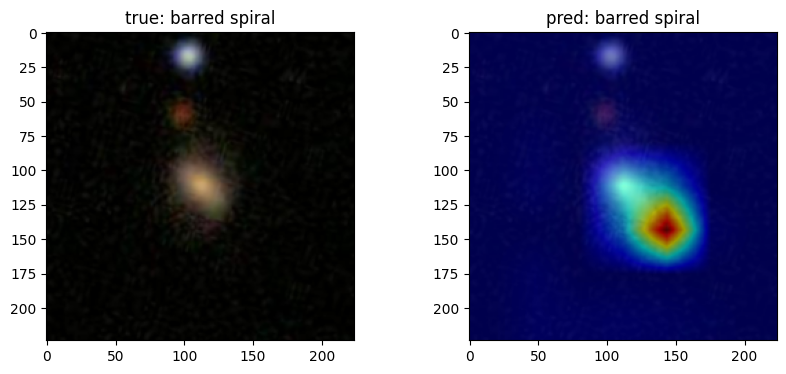

In [18]:
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

img, label = test_dataset[5]
input_tensor = img.unsqueeze(0).to(device)

output = model(input_tensor)
pred_class = output.argmax(dim=1).item()
targets = [ClassifierOutputTarget(pred_class)]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
rgb_img = (img * std + mean).permute(1, 2, 0).numpy()

visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title(f"true: {class_names[label]}")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title(f"pred: {class_names[pred_class]}")
plt.show()

# **plot loss and accuracy curves**

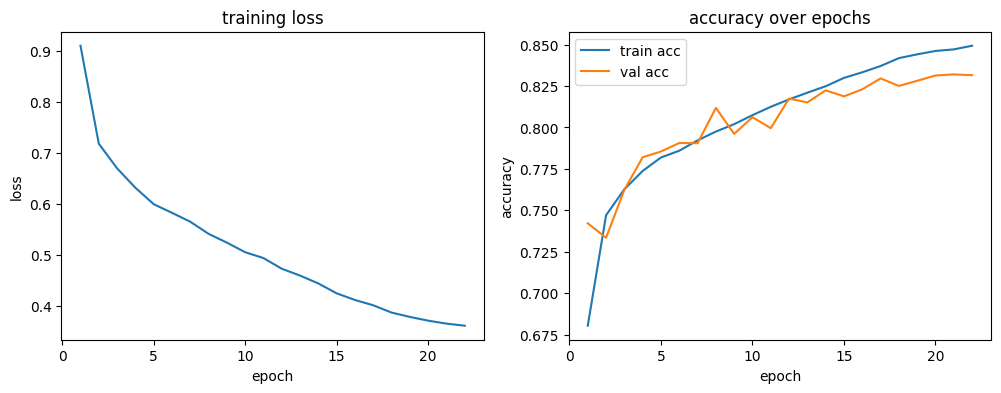

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss_history)+1), train_loss_history)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('training loss')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc_history)+1), train_acc_history, label='train acc')
plt.plot(range(1, len(val_acc_history)+1), val_acc_history, label='val acc')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('accuracy over epochs')
plt.legend()

plt.show()

# **collect predictions on the whole test set, needed for the confusion matrix and report below**

In [20]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# **confusion matrix**

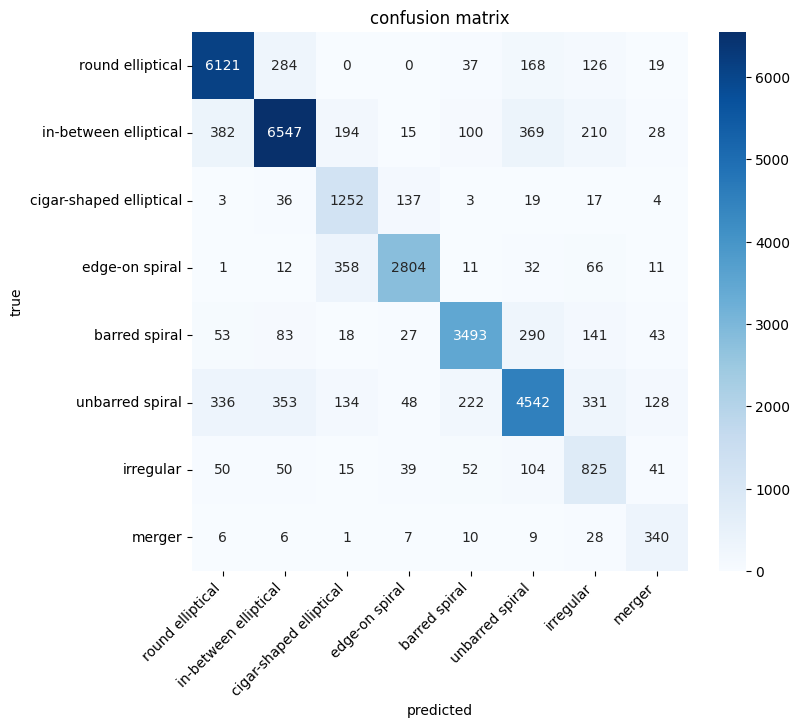

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('predicted')
plt.ylabel('true')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('confusion matrix')
plt.show()

# **precision, recall, f1 per class**

In [22]:
print(classification_report(all_labels, all_preds, target_names=class_names))

                         precision    recall  f1-score   support

       round elliptical       0.88      0.91      0.89      6755
  in-between elliptical       0.89      0.83      0.86      7845
cigar-shaped elliptical       0.63      0.85      0.73      1471
         edge-on spiral       0.91      0.85      0.88      3295
          barred spiral       0.89      0.84      0.87      4148
        unbarred spiral       0.82      0.75      0.78      6094
              irregular       0.47      0.70      0.57      1176
                 merger       0.55      0.84      0.67       407

               accuracy                           0.83     31191
              macro avg       0.76      0.82      0.78     31191
           weighted avg       0.84      0.83      0.83     31191



# **class distribution in the training set**

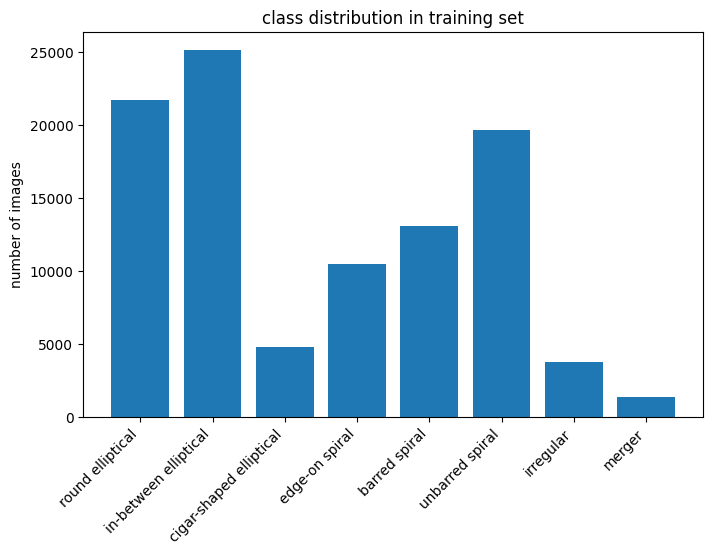

In [23]:
labels_list = data['train']['label']

counts = {}
for label in labels_list:
    if label in counts:
        counts[label] += 1
    else:
        counts[label] = 1

plt.figure(figsize=(8, 5))
plt.bar([class_names[i] for i in range(8)], [counts[i] for i in range(8)])
plt.xticks(rotation=45, ha='right')
plt.ylabel('number of images')
plt.title('class distribution in training set')
plt.show()

# **grab 5 correct and 5 wrong predictions**

In [24]:
correct_examples = []
wrong_examples = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for i in range(len(labels)):
            if preds[i] == labels[i] and len(correct_examples) < 5:
                correct_examples.append((images[i].cpu(), labels[i].item(), preds[i].item()))
            if preds[i] != labels[i] and len(wrong_examples) < 5:
                wrong_examples.append((images[i].cpu(), labels[i].item(), preds[i].item()))

        if len(correct_examples) >= 5 and len(wrong_examples) >= 5:
            break

# **plotting**

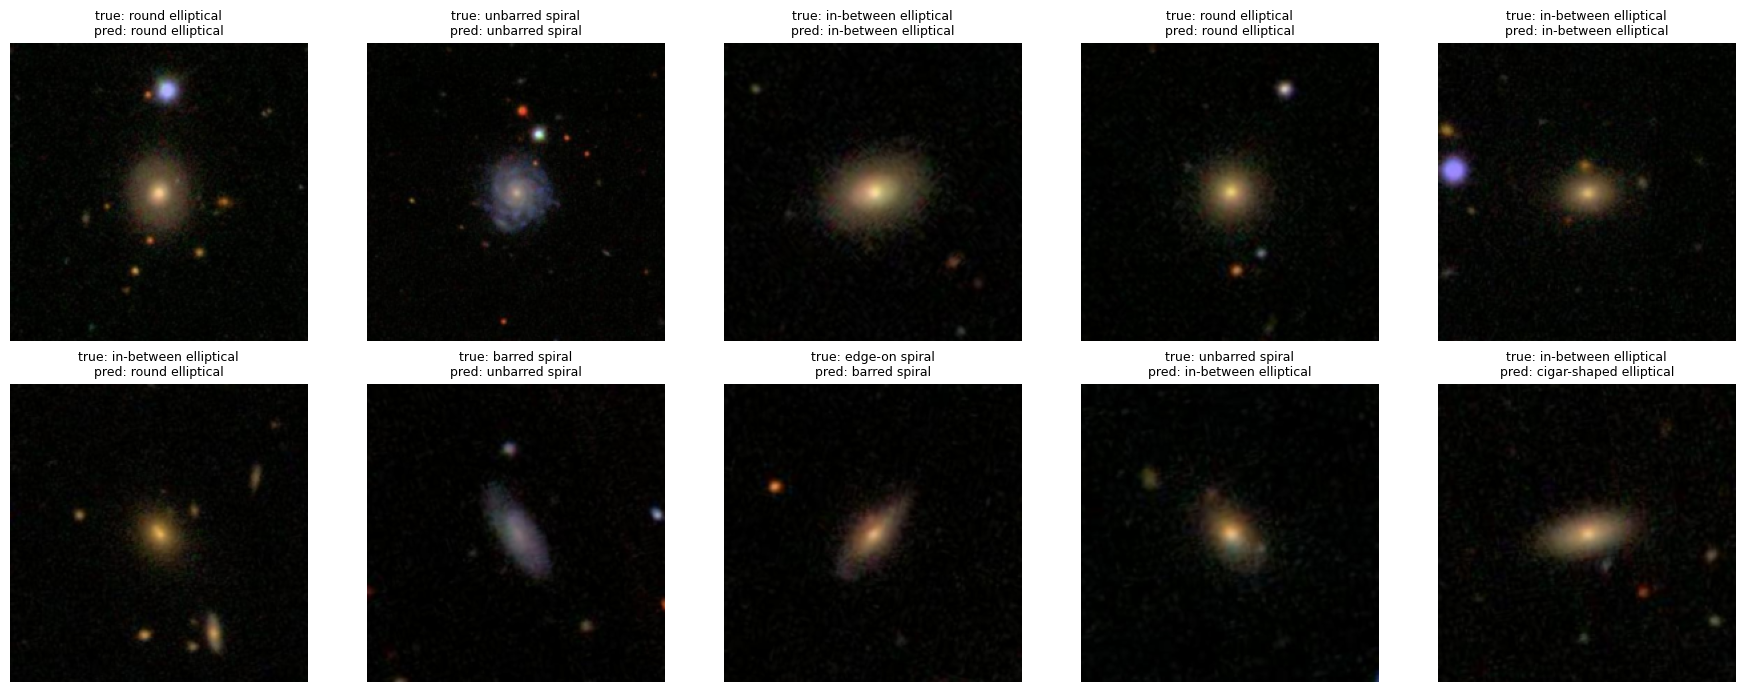

In [25]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, (img, true_label, pred_label) in enumerate(correct_examples):
    img_show = (img * std + mean).permute(1, 2, 0).numpy()
    axes[0, i].imshow(img_show)
    axes[0, i].set_title(f"true: {class_names[true_label]}\npred: {class_names[pred_label]}", fontsize=9)
    axes[0, i].axis('off')

for i, (img, true_label, pred_label) in enumerate(wrong_examples):
    img_show = (img * std + mean).permute(1, 2, 0).numpy()
    axes[1, i].imshow(img_show)
    axes[1, i].set_title(f"true: {class_names[true_label]}\npred: {class_names[pred_label]}", fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# **Grad-CAM across all 8 classes, one example per class**

In [26]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

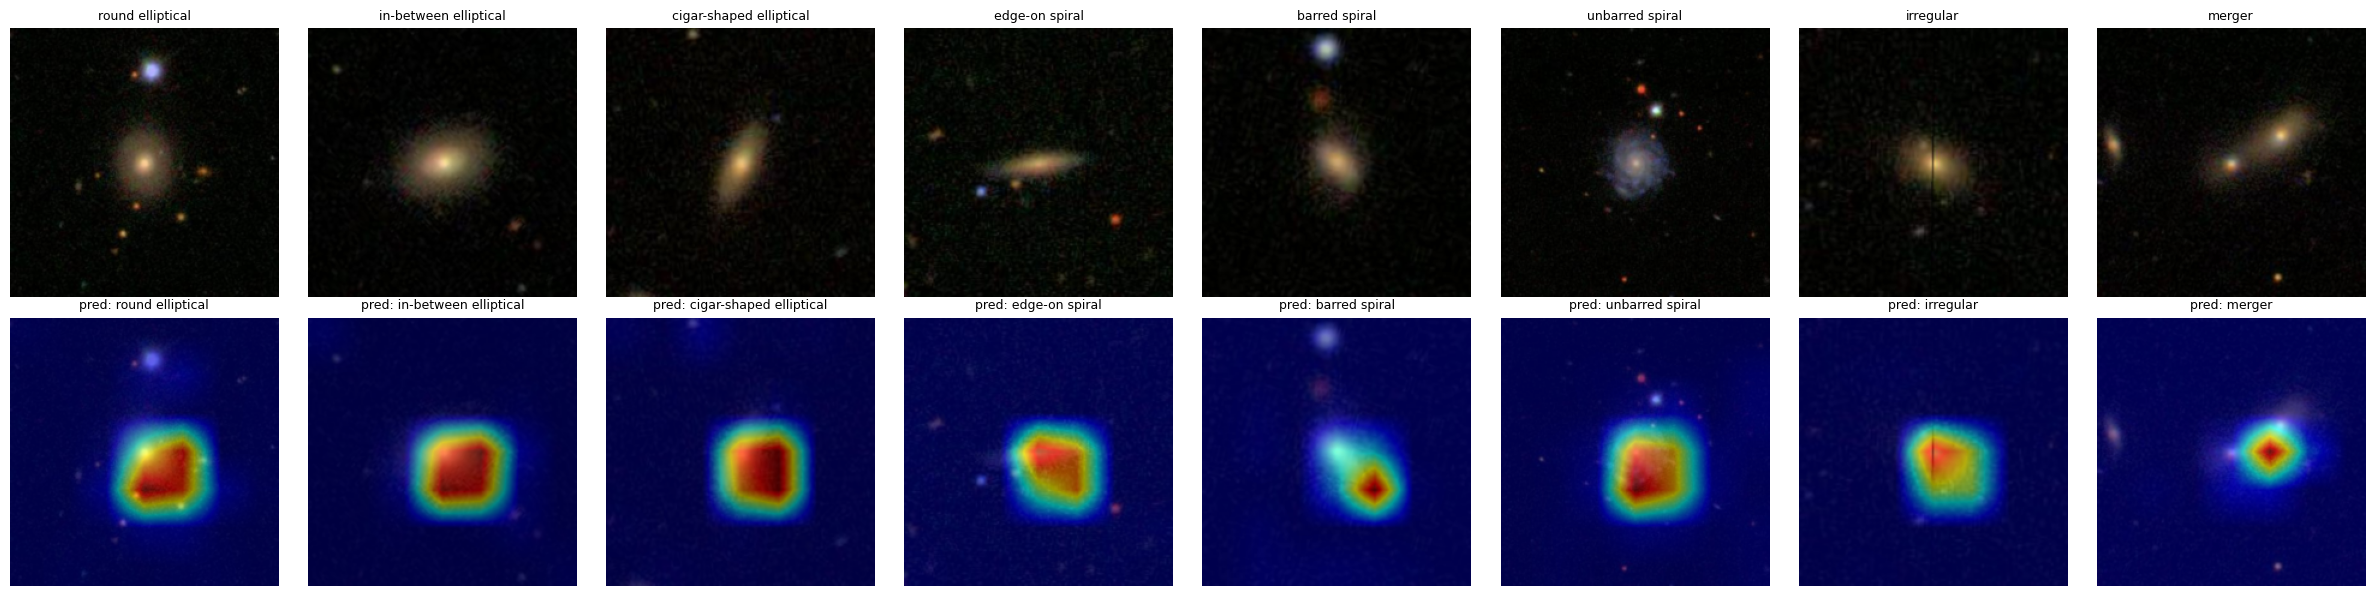

In [27]:
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

fig, axes = plt.subplots(2, 8, figsize=(24, 6))

for class_id in range(8):
    for img, label in test_dataset:
        if label == class_id:
            break

    input_tensor = img.unsqueeze(0).to(device)
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()
    targets = [ClassifierOutputTarget(pred_class)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    rgb_img = (img * std + mean).permute(1, 2, 0).numpy()
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    axes[0, class_id].imshow(rgb_img)
    axes[0, class_id].set_title(class_names[class_id], fontsize=9)
    axes[0, class_id].axis('off')

    axes[1, class_id].imshow(visualization)
    axes[1, class_id].set_title(f"pred: {class_names[pred_class]}", fontsize=9)
    axes[1, class_id].axis('off')

plt.tight_layout()
plt.show()